In [9]:
import pandas as pd 
import numpy as np 
import statsmodels.api as sm
import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option('display.max_columns', None)
df = pd.read_csv('t3.csv')

In [10]:
print(f'shape: {df.shape}')
print(f'\ntreatment distribution:\n{df['d'].value_counts()}')
print(f'\ntreatment rate: {df['d'].mean():.3f}')

print(f'\noutcome summary by treatment group')
print(df.groupby('d')['y'].describe().round(2))

print(f'\nnaive difference in means: {df[df['d']==1]['y'].mean() - df[df['d']==0]['y'].mean():.2f}')

print(f'\ncovariate balance (mean by treatment group)')
covariates = [f'X{i}' for i in range(1, 21)]
balance = df.groupby('d')[covariates].mean().T
balance.columns = ['Control (d=0)', 'Treated (d=1)']
balance['Diff'] = balance['Treated (d=1)'] - balance['Control (d=0)']
print(balance.round(3))

shape: (5000, 22)

treatment distribution:
d
0    2532
1    2468
Name: count, dtype: int64

treatment rate: 0.494

outcome summary by treatment group
    count     mean     std    min     25%     50%     75%     max
d                                                                
0  2532.0  1587.37  437.91 -328.0  1296.0  1604.0  1889.5  2921.0
1  2468.0  1844.19  411.71  347.0  1563.0  1854.0  2132.0  2984.0

naive difference in means: 256.81

covariate balance (mean by treatment group)
     Control (d=0)  Treated (d=1)   Diff
X1          24.065         24.059 -0.005
X2          14.095         14.110  0.015
X3          22.001         22.010  0.009
X4          15.763         15.784  0.022
X5           0.534          0.542  0.008
X6          23.059         23.088  0.029
X7          11.346         11.439  0.093
X8          10.226         10.459  0.233
X9          20.425         20.106 -0.319
X10         15.643         14.784 -0.859
X11         14.512         13.728 -0.784
X12          6

In [11]:
covariates = [f'X{i}' for i in range(1, 21)]

X_naive = sm.add_constant(df[['d']])
model_naive = sm.OLS(df['y'], X_naive).fit(cov_type='HC1')

print('naive OLS (no controls)')
print(f'ATE estimate: {model_naive.params['d']:.2f}')
print(f'std err: {model_naive.bse['d']:.2f}')
print(f'p-value: {model_naive.pvalues['d']:.4f}')
print(f'95% CI: [{model_naive.conf_int().loc['d'][0]:.2f}, {model_naive.conf_int().loc['d'][1]:.2f}]')

#regression adj (w all covariatse)
X_adj = sm.add_constant(df[['d'] + covariates])
model_adj = sm.OLS(df['y'], X_adj).fit(cov_type='HC1')
print('\nregression adjustment (all 20 covariates)')
print(f'ATE estimate: {model_adj.params['d']:.2f}')
print(f'std err: {model_adj.bse['d']:.2f}')
print(f'p-value: {model_adj.pvalues['d']:.4f}')
print(f'95% CI: [{model_adj.conf_int().loc['d'][0]:.2f}, {model_adj.conf_int().loc['d'][1]:.2f}]')

print('\nfull regression summary')
print(model_adj.summary())

naive OLS (no controls)
ATE estimate: 256.81
std err: 12.02
p-value: 0.0000
95% CI: [233.26, 280.37]

regression adjustment (all 20 covariates)
ATE estimate: 15.15
std err: 5.79
p-value: 0.0089
95% CI: [3.81, 26.50]

full regression summary
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     1485.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:12:17   Log-Likelihood:                -32219.
No. Observations:                5000   AIC:                         6.448e+04
Df Residuals:                    4978   BIC:                         6.463e+04
Df Model:                          21                                         
Covariance Type:                  HC1           

propensity score summary
control group - mean: 0.2596, min: 0.0001, max: 0.9934
treated group - mean: 0.7337, min: 0.0178, max: 0.9998


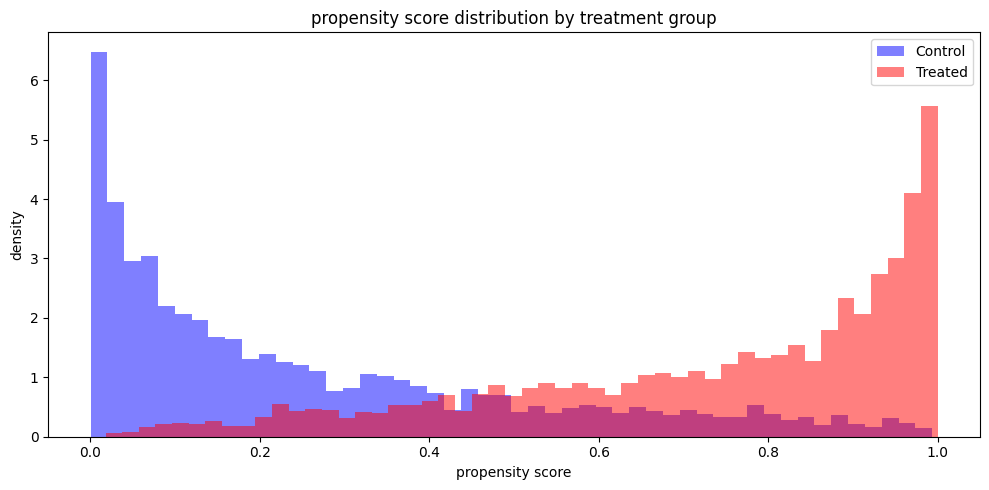

common support range: [0.0178, 0.9934]
observations in common support: 4602 / 5000 (92.0%)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

covariates = [f'X{i}' for i in range(1, 21)]
X = df[covariates].values
y_out = df['y'].values
d = df['d'].values

#est prop scores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=1000, C=1.0)
ps_model.fit(X_scaled, d)
pscore = ps_model.predict_proba(X_scaled)[:, 1]
df["pscore"] = pscore

print('propensity score summary')
print(f'control group - mean: {df[df["d"]==0]["pscore"].mean():.4f}, '
      f'min: {df[df['d']==0]["pscore"].min():.4f}, '
      f'max: {df[df['d']==0]["pscore"].max():.4f}')
print(f'treated group - mean: {df[df['d']==1]["pscore"].mean():.4f}, '
      f'min: {df[df['d']==1]["pscore"].min():.4f}, '
      f'max: {df[df['d']==1]["pscore"].max():.4f}')

#common support 
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(df[df['d']==0]["pscore"], bins=50, alpha=0.5, label='Control', density=True, color='blue')
ax.hist(df[df['d']==1]["pscore"], bins=50, alpha=0.5, label='Treated', density=True, color='red')
ax.set_xlabel('propensity score')
ax.set_ylabel('density')
ax.set_title('propensity score distribution by treatment group')
ax.legend()
plt.tight_layout()
plt.show()

#check overlap region
common_min = max(df[df['d']==0]["pscore"].min(), df[df['d']==1]["pscore"].min())
common_max = min(df[df['d']==0]["pscore"].max(), df[df['d']==1]["pscore"].max())
in_support = ((df["pscore"] >= common_min) & (df["pscore"] <= common_max)).sum()
print(f'common support range: [{common_min:.4f}, {common_max:.4f}]')
print(f'observations in common support: {in_support} / {len(df)} ({in_support/len(df)*100:.1f}%)')

In [13]:
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

covariates = [f'X{i}' for i in range(1, 21)]
X = df[covariates].values 
d = df['d'].values
y_out = df['y'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#prop score 1:1 nearest neigh
ps_model = LogisticRegression(max_iter=1000, C=1.0)
ps_model.fit(X_scaled, d)
pscore = ps_model.predict_proba(X_scaled)[:, 1]
df['pscore'] = pscore 

treated_idx = np.where(d == 1)[0]
control_idx = np.where(d == 0)[0]

nn_ps = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn_ps.fit(pscore[control_idx].reshape(-1, 1))
distances_ps, indices_ps = nn_ps.kneighbors(pscore[treated_idx].reshape(-1, 1))

matched_control_idx_ps = control_idx[indices_ps.flatten()]
att_ps = (y_out[treated_idx] - y_out[matched_control_idx_ps]).mean()
att_ps_se = (y_out[treated_idx] - y_out[matched_control_idx_ps]).std() / np.sqrt(len(treated_idx))

print(f'prop score matching (1:1 NN)')
print(f'ATET estimate: {att_ps}')
print(f'STD err: {att_ps_se}')
print(f'95% CI: [{att_ps - 1.96*att_ps_se}, {att_ps + 1.96*att_ps_se}]')
print(f'mean PS distance: {distances_ps.mean()}')
print(f'max PS distance: {distances_ps.max()}')

#support check 
print(f"control: [{pscore[control_idx].min()}, {pscore[control_idx].max()}]")
print(f"treated: [{pscore[treated_idx].min()}, {pscore[treated_idx].max()}]")


#mahalanobis distance 
cov_matrix = np.cov(X.T)
cov_inv = np.linalg.inv(cov_matrix)

nn_mah = NearestNeighbors(n_neighbors=1, metric='mahalanobis', metric_params={'VI' : cov_inv})
nn_mah.fit(X[control_idx])
distances_mah, indices_mah = nn_mah.kneighbors(X[treated_idx])

matched_control_idx_mah = control_idx[indices_mah.flatten()]
att_mah = (y_out[treated_idx] - y_out[matched_control_idx_mah]).mean()
att_mah_se = (y_out[treated_idx] - y_out[matched_control_idx_mah]).std() / np.sqrt(len(treated_idx))

print(f'mahalanobis distance matching (1:1 NN)')
print(f'ATET estimate: {att_mah}')
print(f'STD err: {att_mah_se}')
print(f'95% CI: [{att_mah - 1.96*att_mah_se}, {att_mah + 1.96*att_mah_se}]')
print(f'mean PS distance: {distances_mah.mean()}')
print(f'max PS distance: {distances_mah.max()}')

#matching quality
print('covariate balance after matching (std mean diff)')
print(f"{'method':<15} {'mean |SMD|':>12} {'max |SMD|':>12}\n{'-' * 42}")
for name, matched_ctrl_idx in [('PS Match', matched_control_idx_ps), ('Mahalanobis', matched_control_idx_mah)]:
    smds = []
    for col in covariates: 
        treated_vals = df.loc[treated_idx, col].values 
        control_vals = df.loc[matched_ctrl_idx, col].values 
        pooled_std = np.sqrt((treated_vals.var() + control_vals.var()) / 2)
        if pooled_std > 0: 
            smd = abs(treated_vals.mean() - control_vals.mean()) / pooled_std
        else: 
            smd = 0 
        smds.append(smd)
    print(f'{name:<15} {np.mean(smds):>12.4f} {np.max(smds):>12.4f}')


prop score matching (1:1 NN)
ATET estimate: -2.401539708265802
STD err: 10.86664959388228
95% CI: [-23.700172912275068, 18.897093495743466]
mean PS distance: 0.0006414092179794127
max PS distance: 0.006410513573759324
control: [5.235242886897245e-05, 0.9934261103936177]
treated: [0.017764962271901913, 0.999836623967377]
mahalanobis distance matching (1:1 NN)
ATET estimate: 150.85129659643437
STD err: 7.660488275297928
95% CI: [135.83673957685042, 165.8658536160183]
mean PS distance: 3.4495566129441113
max PS distance: 5.372612798799318
covariate balance after matching (std mean diff)
method            mean |SMD|    max |SMD|
------------------------------------------
PS Match              0.0750       0.2424
Mahalanobis           0.1976       1.0309


In [14]:
from sklearn.linear_model import LinearRegression, LogisticRegression

covariates = [f'X{i}' for i in range(1, 21)]
X = df[covariates].values 
d = df['d'].values
y_out = df['y'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#IPW est
ps_model = LogisticRegression(max_iter=1000, C=1.0)
ps_model.fit(X_scaled, d)
pscore = ps_model.predict_proba(X_scaled)[:, 1]

#clip prop scores to avoid insane weights 
pscore_clipped = np.clip(pscore, 0.01, 0.99)

ipw_ate = np.mean(y_out * (d / pscore_clipped - (1 - d) / (1 - pscore_clipped)))

#bootstrap for std err 
np.random.seed(42)
n_boot = 1000
boot_ipw = []

for _ in range(n_boot):
    idx = np.random.choice(len(y_out), size=len(y_out), replace=True)
    ps_b = LogisticRegression(max_iter=1000, C=1.0)
    ps_b.fit(X_scaled[idx], d[idx])
    ps_hat = np.clip(ps_b.predict_proba(X_scaled[idx])[:, 1], 0.01, 0.99)
    boot_ipw.append(np.mean(y_out[idx] * (d[idx] / ps_hat - (1 - d[idx]) / (1 - ps_hat))))

ipw_se = np.std(boot_ipw)
print(f'ipw estimator')
print(f'ATE estimate: {ipw_ate}')
print(f'bootstrap SE: {ipw_se}')
print(f'95% CI: [{ipw_ate - 1.96*ipw_se}, {ipw_ate + 1.96*ipw_se}]')

#check weight dist
weights_treated = 1 / pscore_clipped[d == 1]
weights_control = 1 / (1 - pscore_clipped[d == 1])
print('\nweight diagnostics')
print(f'treated weights  - mean: {weights_treated.mean():.2f}, max: {weights_treated.max():.2f}')
print(f'control weights  - mean: {weights_control.mean():.2f}, max: {weights_control.max():.2f}')

#AIPW est
X_treated = X_scaled[d == 1]
X_control = X_scaled[d == 0]
y_treated = y_out[d == 1]
y_control = y_out[d == 0]

mu1_model = LinearRegression().fit(X_treated, y_treated)
mu0_model = LinearRegression().fit(X_control, y_control)

mu1_hat = mu1_model.predict(X_scaled)
mu0_hat = mu0_model.predict(X_scaled)

aipw_ate = np.mean(
    (d / pscore_clipped) * (y_out - mu1_hat) + mu1_hat
    - ((1 - d) / (1 - pscore_clipped)) * (y_out - mu0_hat) - mu0_hat
)

#bootsrap for AIPW SE 
boot_aipw = []
np.random.seed(42)
for _ in range(n_boot):
    idx = np.random.choice(len(y_out), size=len(y_out), replace=True)
    #prop model
    ps_b = LogisticRegression(max_iter=1000, C=1.0)
    ps_b.fit(X_scaled[idx], d[idx])
    ps_hat = np.clip(ps_b.predict_proba(X_scaled[idx])[:, 1], 0.01, 0.99)
    #outcome models
    m1 = LinearRegression().fit(X_scaled[idx][d[idx]==1], y_out[idx][d[idx]==1])
    m0 = LinearRegression().fit(X_scaled[idx][d[idx]==0], y_out[idx][d[idx]==0])
    mu1_b = m1.predict(X_scaled[idx])
    mu0_b = m0.predict(X_scaled[idx])
    #AIPW
    ate_b = np.mean(
        (d[idx] / ps_hat) * (y_out[idx] - mu1_b) + mu1_b
        - ((1 - d[idx]) / (1 - ps_hat)) * (y_out[idx] - mu0_b) - mu0_b
    )
    boot_aipw.append(ate_b)

aipw_se = np.std(boot_aipw)
print(f'AIPW estimator (linear + logistic)')
print(f'ATE estimate: {aipw_ate:.2f}')
print(f'Bootstrap SE: {aipw_se:.2f}')
print(f'95% CI: [{aipw_ate - 1.96*aipw_se:.2f}, {aipw_ate + 1.96*aipw_se:.2f}]')

ipw estimator
ATE estimate: -311.6858086437184
bootstrap SE: 81.21435043863885
95% CI: [-470.86593550345054, -152.5056817839863]

weight diagnostics
treated weights  - mean: 1.81, max: 56.29
control weights  - mean: 17.44, max: 100.00
AIPW estimator (linear + logistic)
ATE estimate: 18.85
Bootstrap SE: 8.42
95% CI: [2.34, 35.35]


In [15]:
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, KFold 
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

covariates = [f'X{i}' for i in range(1, 21)]
X = df[covariates].values 
d = df['d'].values
y_out = df['y'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def dml_estimate(y_model, d_model, X_data, y_data, d_data, name):
    #X-fitted resids 
    y_hat = cross_val_predict(y_model, X_data, y_data, cv=kf)
    d_hat = cross_val_predict(d_model, X_data, d_data, cv=kf)

    if hasattr(d_model, 'predict_proba'):
        d_hat_prob = cross_val_predict(d_model, X_data, d_data, cv=kf, method='predict_proba')[:, 1]
    else: 
        d_hat_prob = d_hat 

    y_resid = y_data - y_hat 
    d_resid = d_data - d_hat_prob 

    #OLS 
    theta = np.sum(d_resid * y_resid) / np.sum(d_resid * y_resid)

    #std err
    n = len(y_data)
    residuals = y_resid - theta * d_resid
    V = np.mean(d_resid**2)
    se = np.sqrt(np.mean((d_resid * residuals)**2) / (n * V**2))
    z = theta / se
    p_value = 2 * (1 - norm.cdf(abs(z)))


    print(f'DML: {name}')
    print(f'ATE estimate: {theta:.2f}')
    print(f'Std err: {se:.2f}')
    print(f'95% CI: [{theta - 1.96*se:.2f}, {theta + 1.96*se:.2f}]')
    print(f'p-value: {p_value}')
    return theta, se

#lasso + logistic lasso 
theta_lasso, se_lasso = dml_estimate(
    LassoCV(cv=5, random_state=42),
    LogisticRegressionCV(cv=5, penalty='l1', solver='saga', max_iter=2000, random_state=42),
    X_scaled, y_out, d, 'Lasso + Logistic Lasso'
)

#rf 
theta_rf, se_rf = dml_estimate(
    RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20, random_state=42),
    RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=20, random_state=42),
    X_scaled, y_out, d, 'Random Forest'
)

#GB
theta_gb, se_gb = dml_estimate(
    GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
    GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
    X_scaled, y_out, d, 'Gradient boosting'
)

print(f"{'ML Method':<25} {'ATE':>8} {'SE':>8} {'95% CI'}")
print('-' * 65)
for name, theta, se in [('Lasso', theta_lasso, se_lasso), 
                         ('Random Forest', theta_rf, se_rf),
                         ('Gradient Boosting', theta_gb, se_gb)]:
    print(f'{name:<25} {theta:>8.2f} {se:>8.2f}   [{theta-1.96*se:.2f}, {theta+1.96*se:.2f}]')

DML: Lasso + Logistic Lasso
ATE estimate: 1.00
Std err: 6.00
95% CI: [-10.77, 12.77]
p-value: 0.8677392655413607
DML: Random Forest
ATE estimate: 1.00
Std err: 5.83
95% CI: [-10.42, 12.42]
p-value: 0.863697423891318
DML: Gradient boosting
ATE estimate: 1.00
Std err: 5.94
95% CI: [-10.65, 12.65]
p-value: 0.8663862311298867
ML Method                      ATE       SE 95% CI
-----------------------------------------------------------------
Lasso                         1.00     6.00   [-10.77, 12.77]
Random Forest                 1.00     5.83   [-10.42, 12.42]
Gradient Boosting             1.00     5.94   [-10.65, 12.65]
